# 🏪 Store Sales Forecasting
## Future Interns ML Task 1 — Regression Model

**Goal:** Predict future store sales using historical data.  
**Model:** Gradient Boosting Regressor  
**Data:** Corporación Favorita grocery stores, Ecuador (2013–2017)

In [3]:

# IMPORT LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [4]:

# LOAD DATA


train    = pd.read_csv('../data/train.csv',           parse_dates=['date'])
test     = pd.read_csv('../data/test.csv',            parse_dates=['date'])
stores   = pd.read_csv('../data/stores.csv')
oil      = pd.read_csv('../data/oil.csv',             parse_dates=['date'])
holidays = pd.read_csv('../data/holidays_events.csv', parse_dates=['date'])

print(f"✅ Data loaded!")
print(f"Train : {len(train):,} rows")
print(f"Test  : {len(test):,} rows")
print(f"Dates : {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Stores: {train['store_nbr'].nunique()} unique stores")
print(f"Families: {train['family'].nunique()} product categories")
train.head()

✅ Data loaded!
Train : 3,000,888 rows
Test  : 28,512 rows
Dates : 2013-01-01 → 2017-08-15
Stores: 54 unique stores
Families: 33 product categories


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:

# CLEAN & MERGE DATA


# Fix oil price gaps (weekends have no price — carry last known forward)
oil = oil.rename(columns={'dcoilwtico': 'oil_price'})
oil = oil.set_index('date').resample('D').first().ffill().bfill().reset_index()

# Keep only national holidays
nat_hols = holidays[
    (holidays['locale'] == 'National') &
    (holidays['transferred'] == False)
][['date']].drop_duplicates()
nat_hols['is_holiday'] = 1

# Merge store info, oil price, holiday flag into train
train = train.merge(stores,   on='store_nbr', how='left')
train = train.merge(oil,      on='date',      how='left')
train = train.merge(nat_hols, on='date',      how='left')
train['is_holiday'] = train['is_holiday'].fillna(0).astype(int)
train['oil_price']  = train['oil_price'].fillna(train['oil_price'].median())

# Same for test
test = test.merge(stores,   on='store_nbr', how='left')
test = test.merge(oil,      on='date',      how='left')
test = test.merge(nat_hols, on='date',      how='left')
test['is_holiday'] = test['is_holiday'].fillna(0).astype(int)
test['oil_price']  = test['oil_price'].fillna(train['oil_price'].median())

print("✅ Cleaned and merged!")
print(f"Columns: {list(train.columns)}")

✅ Cleaned and merged!
Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'is_holiday']


In [6]:

# FEATURE ENGINEERING
# Extract useful signals from the date
# ML models only understand numbers 

def create_features(df):
    df = df.copy()
    df['year']             = df['date'].dt.year
    df['month']            = df['date'].dt.month
    df['day']              = df['date'].dt.day
    df['day_of_week']      = df['date'].dt.dayofweek   # 0=Mon 6=Sun
    df['week']             = df['date'].dt.isocalendar().week.astype(int)
    df['quarter']          = df['date'].dt.quarter
    df['is_weekend']       = (df['day_of_week'] >= 5).astype(int)
    df['is_month_start']   = df['date'].dt.is_month_start.astype(int)
    df['is_month_end']     = df['date'].dt.is_month_end.astype(int)
    df['days_since_start'] = (df['date'] - pd.Timestamp('2013-01-01')).dt.days
    return df

train = create_features(train)
test  = create_features(test)

# Encode text → numbers 
for col in ['family', 'city', 'state', 'type']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    train[f'{col}_enc'] = le.transform(train[col])
    test[f'{col}_enc']  = le.transform(test[col])

print("✅ Features created!")
print(f"Total columns: {len(train.columns)}")

✅ Features created!
Total columns: 26


In [7]:

# PREPARE FEATURES & SPLIT


# Use 10% sample for speed
train_sample = train.sample(frac=0.10, random_state=42).reset_index(drop=True)

FEATURES = [
    'store_nbr', 'family_enc', 'onpromotion', 'cluster',
    'city_enc', 'state_enc', 'type_enc', 'oil_price', 'is_holiday',
    'year', 'month', 'day', 'day_of_week', 'week', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end', 'days_since_start'
]
TARGET = 'sales'

X = train_sample[FEATURES]
y = train_sample[TARGET]

# Split by TIME — last 15% of dates = validation
split_date = pd.Timestamp(
    train_sample['date'].sort_values().iloc[int(len(train_sample) * 0.85)]
)
train_mask = train_sample['date'] <= split_date
val_mask   = train_sample['date'] >  split_date

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Split date      : {split_date.date()}")
print(f"Training rows   : {len(X_train):,}")
print(f"Validation rows : {len(X_val):,}")

Split date      : 2016-12-05
Training rows   : 255,095
Validation rows : 44,994


In [8]:

# TRAIN MODELS


print("📈 Training Linear Regression (baseline)...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = np.clip(lr_model.predict(X_val), 0, None)
print("   ✅ Done!")

print("\n🚀 Training Gradient Boosting (~1 minute)...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_preds = np.clip(gb_model.predict(X_val), 0, None)
print("   ✅ Done!")

📈 Training Linear Regression (baseline)...
   ✅ Done!

🚀 Training Gradient Boosting (~1 minute)...
   ✅ Done!


In [9]:

# EVALUATE PERFORMANCE


def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n📊 {name}")
    print(f"   MAE  → average error of {mae:,.2f} units")
    print(f"   RMSE → {rmse:,.2f}")
    print(f"   R²   → explains {r2*100:.1f}% of sales variation")
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate("Linear Regression (Baseline)", y_val, lr_preds)
gb_mae, gb_rmse, gb_r2 = evaluate("Gradient Boosting (Main Model)", y_val, gb_preds)

print(f"\n✅ GBR improved error by {(lr_mae-gb_mae)/lr_mae*100:.1f}% over baseline!")


📊 Linear Regression (Baseline)
   MAE  → average error of 469.27 units
   RMSE → 1,075.80
   R²   → explains 36.7% of sales variation

📊 Gradient Boosting (Main Model)
   MAE  → average error of 275.07 units
   RMSE → 728.60
   R²   → explains 71.0% of sales variation

✅ GBR improved error by 41.4% over baseline!


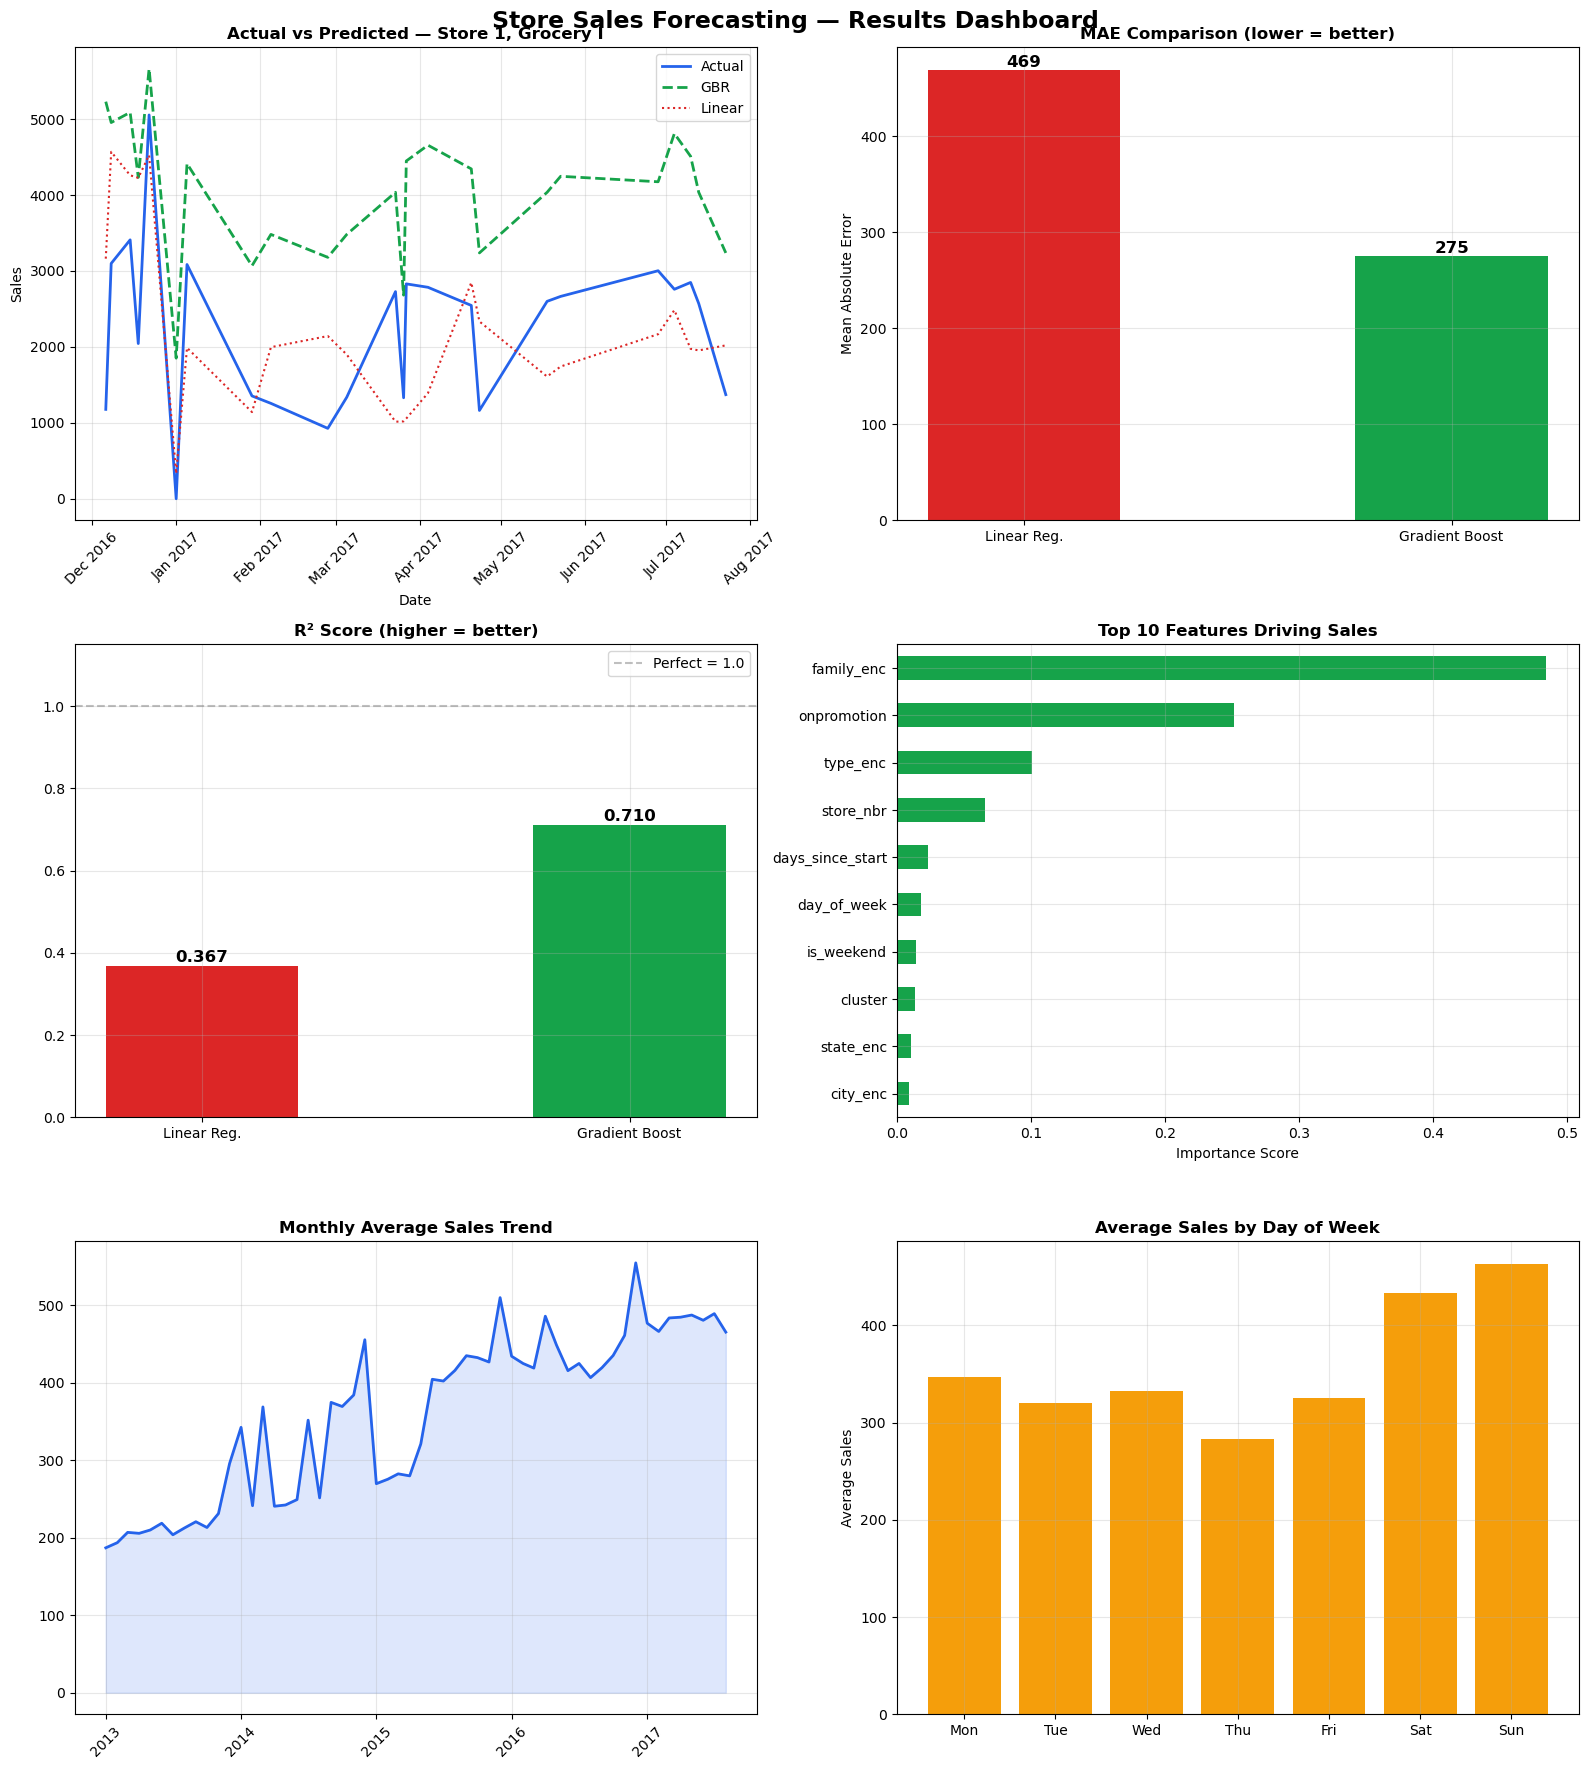

✅ Chart saved!


In [11]:

#  VISUALIZATIONS


fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Store Sales Forecasting — Results Dashboard',
             fontsize=17, fontweight='bold')
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3})
C = {'actual':'#2563EB','gbr':'#16A34A','lr':'#DC2626','hl':'#F59E0B'}

# Chart 1 Actual vs Predicted
ax1 = axes[0, 0]
m   = (train_sample[val_mask]['store_nbr']==1) & \
      (train_sample[val_mask]['family']=='GROCERY I')
idx = m[m].index
if len(idx) > 0:
    dates_s = train_sample[val_mask].loc[idx,'date'].values
    act_s   = y_val.loc[idx].values
    gb_s    = gb_preds[m.values]
    lr_s    = lr_preds[m.values]
    si      = np.argsort(dates_s)
    ax1.plot(dates_s[si], act_s[si], color=C['actual'], label='Actual', lw=2)
    ax1.plot(dates_s[si], gb_s[si],  color=C['gbr'],   label='GBR',    lw=2,   ls='--')
    ax1.plot(dates_s[si], lr_s[si],  color=C['lr'],    label='Linear', lw=1.5, ls=':')
ax1.set_title('Actual vs Predicted — Store 1, Grocery I', fontweight='bold')
ax1.legend(); ax1.set_xlabel('Date'); ax1.set_ylabel('Sales')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Chart 2 MAE Comparison
ax2 = axes[0, 1]
bars2 = ax2.bar(['Linear Reg.','Gradient Boost'], [lr_mae, gb_mae],
                color=[C['lr'], C['gbr']], width=0.45)
for b, v in zip(bars2, [lr_mae, gb_mae]):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+3,
             f'{v:,.0f}', ha='center', fontweight='bold', fontsize=12)
ax2.set_title('MAE Comparison (lower = better)', fontweight='bold')
ax2.set_ylabel('Mean Absolute Error')

# Chart 3 R² Comparison
ax3 = axes[1, 0]
bars3 = ax3.bar(['Linear Reg.','Gradient Boost'], [max(0,lr_r2), max(0,gb_r2)],
                color=[C['lr'], C['gbr']], width=0.45)
for b, v in zip(bars3, [lr_r2, gb_r2]):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
             f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)
ax3.axhline(1.0, color='gray', ls='--', alpha=0.5, label='Perfect = 1.0')
ax3.set_title('R² Score (higher = better)', fontweight='bold')
ax3.set_ylim(0, 1.15); ax3.legend()

# Chart 4 Feature Importance
ax4 = axes[1, 1]
imps = pd.Series(gb_model.feature_importances_, index=FEATURES).sort_values()
imps.tail(10).plot(kind='barh', ax=ax4, color=C['gbr'])
ax4.set_title('Top 10 Features Driving Sales', fontweight='bold')
ax4.set_xlabel('Importance Score')

# Chart 5 Monthly Sales Trend
ax5 = axes[2, 0]
monthly = train.groupby(train['date'].dt.to_period('M'))['sales'].mean()
monthly.index = monthly.index.to_timestamp()
ax5.plot(monthly.index, monthly.values, color=C['actual'], lw=2)
ax5.fill_between(monthly.index, monthly.values, alpha=0.15, color=C['actual'])
ax5.set_title('Monthly Average Sales Trend', fontweight='bold')
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45)

# Chart 6 Sales by Day of Week
ax6 = axes[2, 1]
dow_sales = train.groupby(train['date'].dt.dayofweek)['sales'].mean()
ax6.bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
        dow_sales.values, color=C['hl'])
ax6.set_title('Average Sales by Day of Week', fontweight='bold')
ax6.set_ylabel('Average Sales')

plt.tight_layout()
plt.savefig('../sales_forecasting_results.png', dpi=130,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart saved!")